In [1]:

#from qcodes_contrib_drivers.drivers.Keysight.Keysight_P9373A import P9373A
from pycqed.instrument_drivers.physical_instruments.KST_VNA import KST_VNA
from pycqed.measurement import detector_functions as det
from pycqed.measurement import mc_parameter_wrapper as pw
from pycqed.measurement import sweep_functions as swf
from pycqed.analysis import measurement_analysis as ma
from pycqed.analysis_v2 import measurement_analysis as ma2
from pycqed.measurement import measurement_control
from pycqed.instrument_drivers.meta_instrument.qubit_objects import QLab_Neon as eNeQ
from qcodes_contrib_drivers.drivers.QDevil import QDAC2
from qcodes.instrument_drivers.Anritsu import MG369xC
import pycqed.analysis.analysis_toolbox as a_tools
import numpy as np
import time

import qcodes as qc
from qcodes import Station

import pyvisa as visa
rm = visa.ResourceManager()
#rm.list_resources()
#%matplotlib qt

C:\Users\cnmuser\.conda\envs\pycqed\lib\site-packages\visa.py:13: FutureWarning: The visa module provided by PyVISA is being deprecated. You can replace `import visa` by `import pyvisa as visa` to achieve the same effect.

The reason for the deprecation is the possible conflict with the visa package provided by the https://github.com/visa-sdk/visa-python which can result in hard to debug situations.
  warnings.warn(


This is the version by Stefano, there is another version in QCoDeS
C:\Users\cnmuser\PycQED\PycQED_py3\data
Data directory set to: C:\Users\cnmuser\PycQED\PycQED_py3\data
C:\Users\cnmuser\PycQED\PycQED_py3\data
Data directory set to: C:\Users\cnmuser\PycQED\PycQED_py3\data
C:\Users\cnmuser\PycQED\PycQED_py3\data
Data directory set to: C:\Users\cnmuser\PycQED\PycQED_py3\data
C:\Users\cnmuser\PycQED\PycQED_py3\data
Data directory set to: C:\Users\cnmuser\PycQED\PycQED_py3\data
C:\Users\cnmuser\PycQED\PycQED_py3\data
Data directory set to: C:\Users\cnmuser\PycQED\PycQED_py3\data
C:\Users\cnmuser\PycQED\PycQED_py3\data
Data directory set to: C:\Users\cnmuser\PycQED\PycQED_py3\data


C:\Users\cnmuser\.conda\envs\pycqed\lib\site-packages\Cython\Compiler\Main.py:346: FutureWarning: Cython directive 'language_level' not set, using '3str' for now (Py3). This has changed from earlier releases! File: C:\Users\cnmuser\.conda\envs\pycqed\lib\site-packages\pygsti\objects\fastgatecalc.pyx
  tree = Parsing.p_module(s, pxd, full_module_name)

Error compiling Cython file:
------------------------------------------------------------
...
    my_map[2]=6.2
    my_map2 = my_map
    my_map2[2]=10.0
    my_map2[3]=20.0
    
    print my_map[1],my_map[2]
         ^
------------------------------------------------------------

C:\Users\cnmuser\.conda\envs\pycqed\lib\site-packages\pygsti\objects\fastgatecalc.pyx:36:10: Syntax error in simple statement list

Error compiling Cython file:
------------------------------------------------------------
...
    my_map[2]=6.2
    my_map2 = my_map
    my_map2[2]=10.0
    my_map2[3]=20.0
    
    print my_map[1],my_map[2]
         ^
--------------

C:\Users\cnmuser\PycQED\PycQED_py3\data


In [1]:
from pymeasure.instruments.yokogawa import YokogawaGS200
gs200 = YokogawaGS200("GPIB1::1::INSTR")

C:\Users\cnmuser\.conda\envs\pycqed\lib\site-packages\pymeasure\instruments\generic_types.py:110: FutureWarning: It is not known whether this device support SCPI commands or not. Please inform the pymeasure maintainers if you know the answer.
  warn("It is not known whether this device support SCPI commands or not. Please inform "


In [3]:
# Replace with your VISA resource string
vna = KST_VNA(name='N5222B3', address = 'USB0::0x2A8D::0x2A01::MY58421887::0::INSTR')
sgen = MG369xC.ANRITSU_MG369xC(name='MG3692C', address='GPIB0::5::INSTR') 


Connected to: Keysight Technologies N5222B (serial:MY58421887, firmware:A.13.50.09) in 0.22s
Connected to: ANRITSU MG3692C (serial:201201, firmware:3.62) in 0.50s


In [4]:
###############################################################################
# MC and monitor
###############################################################################
station = Station()
# The measurement control is used to control experiments (see tutorial 1.)
MC = measurement_control.MeasurementControl(
    'MC', live_plot_enabled=True, verbose=True)
MC.station = station
station.add_component(MC)
MC.live_plot_enabled(True)

# Required to set it to the testing datadir
a_tools.datadir='C:/Data_IS/snail-June/'
MC.datadir(a_tools.datadir)

station.add_component(vna)
#station.add_component(sgen)

from pycqed.instrument_drivers.virtual_instruments import instrument_monitor as im 
IM = im.InstrumentMonitor('IM', station)
station.add_component(IM)
# Link the instrument monitor to the MC so that it gets updated in the loop
MC.instrument_monitor('IM')
IM.update()

Q1 = eNeQ.QLab_Neon('Q1', MC, vna)


None


Current Source parameter setup

Initalize gs200

In [2]:
gs200.source_mode = 'current' # or 'current'
gs200.source_range = 0.2 # I range
gs200.voltage_limit = 2 # V protection limit
current = 0

run the test VNA scan

Initalize and setting for signal generator

In [8]:
sgen.on("OFF")
sgpower = 10 #-20 to 30dbm
pump_freq = 8.19009e9*2 #2f
#pump_freq = 8.184e9 + 10e6 #2f
sgen.power(sgpower)
sgen.frequency(pump_freq)
sgen.on("ON")

Test scan

7633000000.0 7653000000.0
Starting measurement: resonator_vna_scan_frquency_7633000000.0_to_7653000000.0_power_0__Q1
Sweep function: KST_VNA_sweep
Detector function: KST_VNA_detector
 100% completed 	elapsed time: 38.8s 	time left: 0.0s


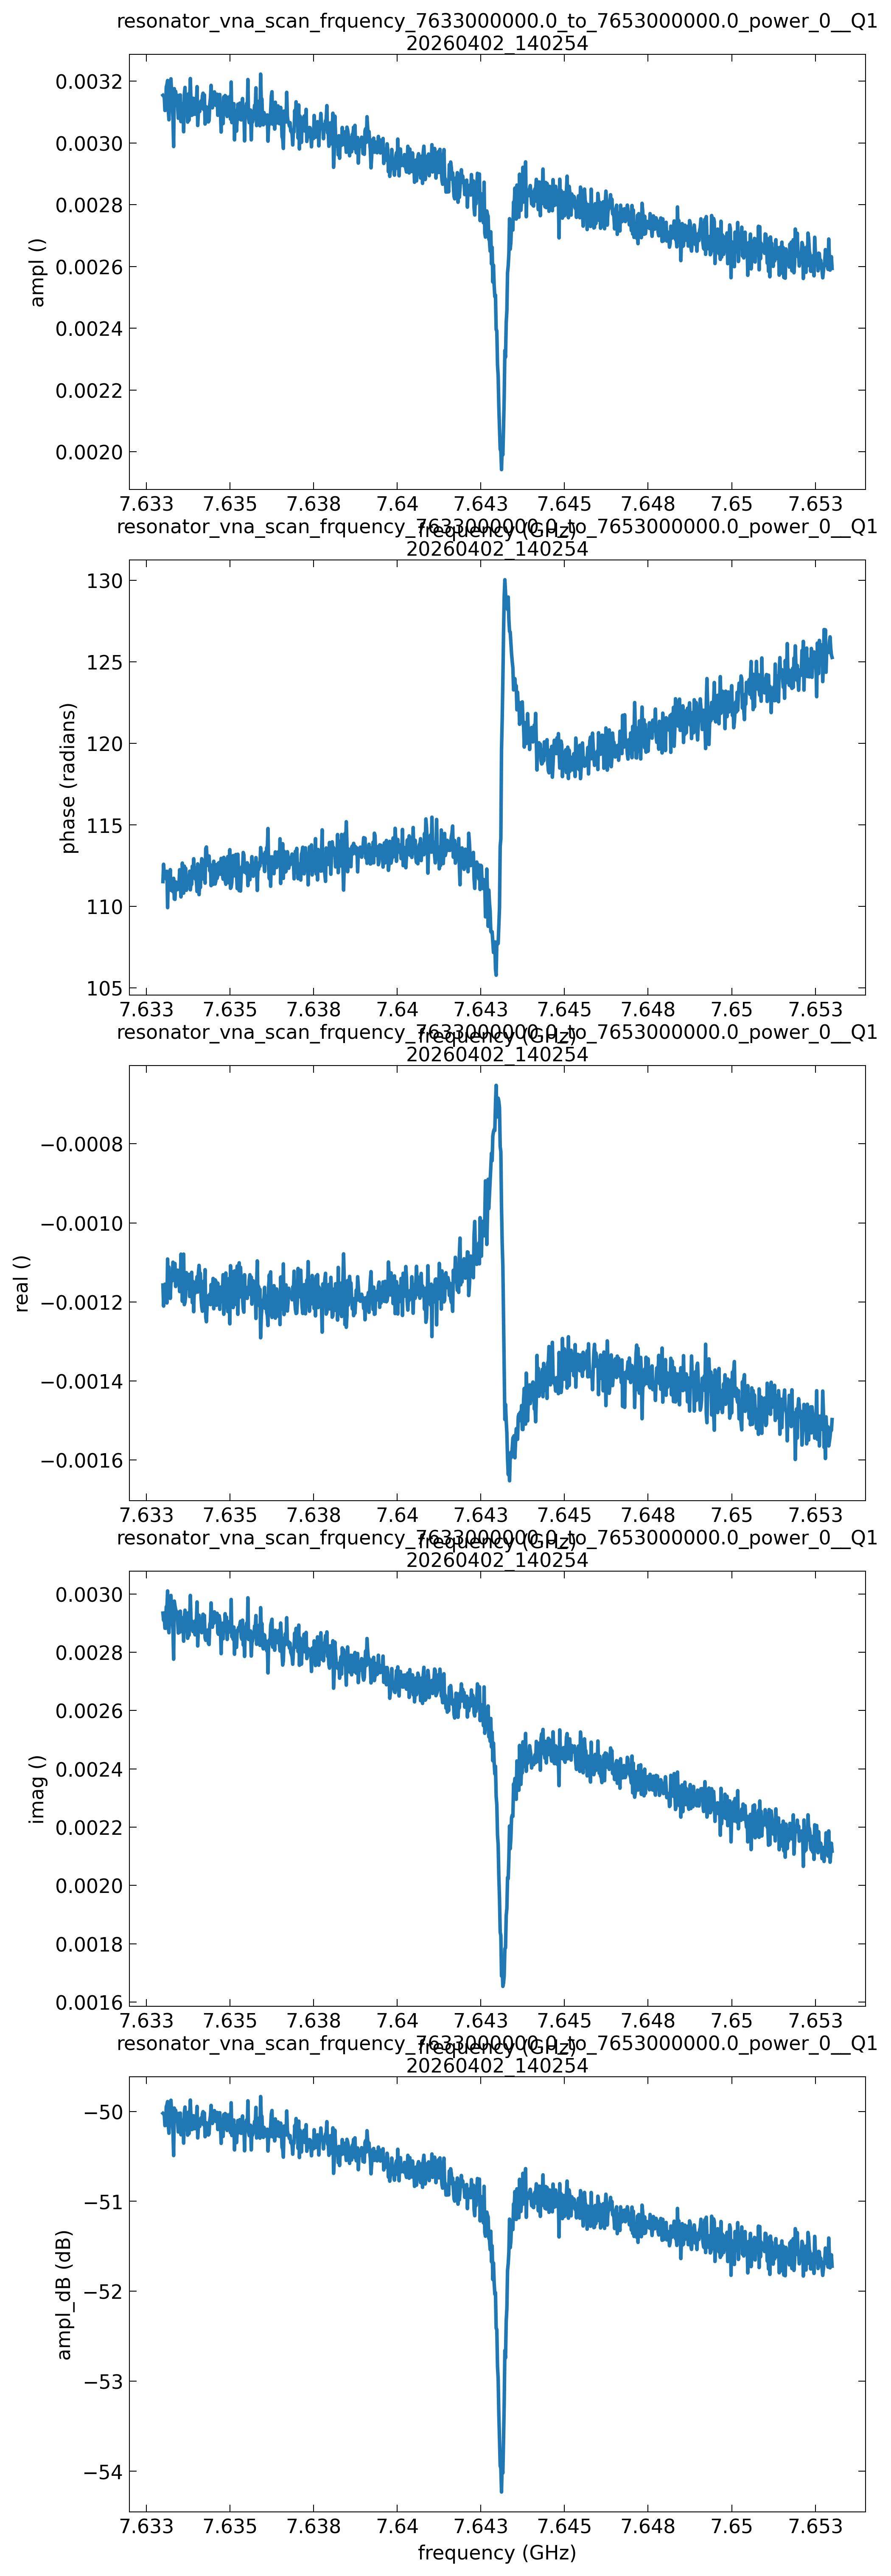

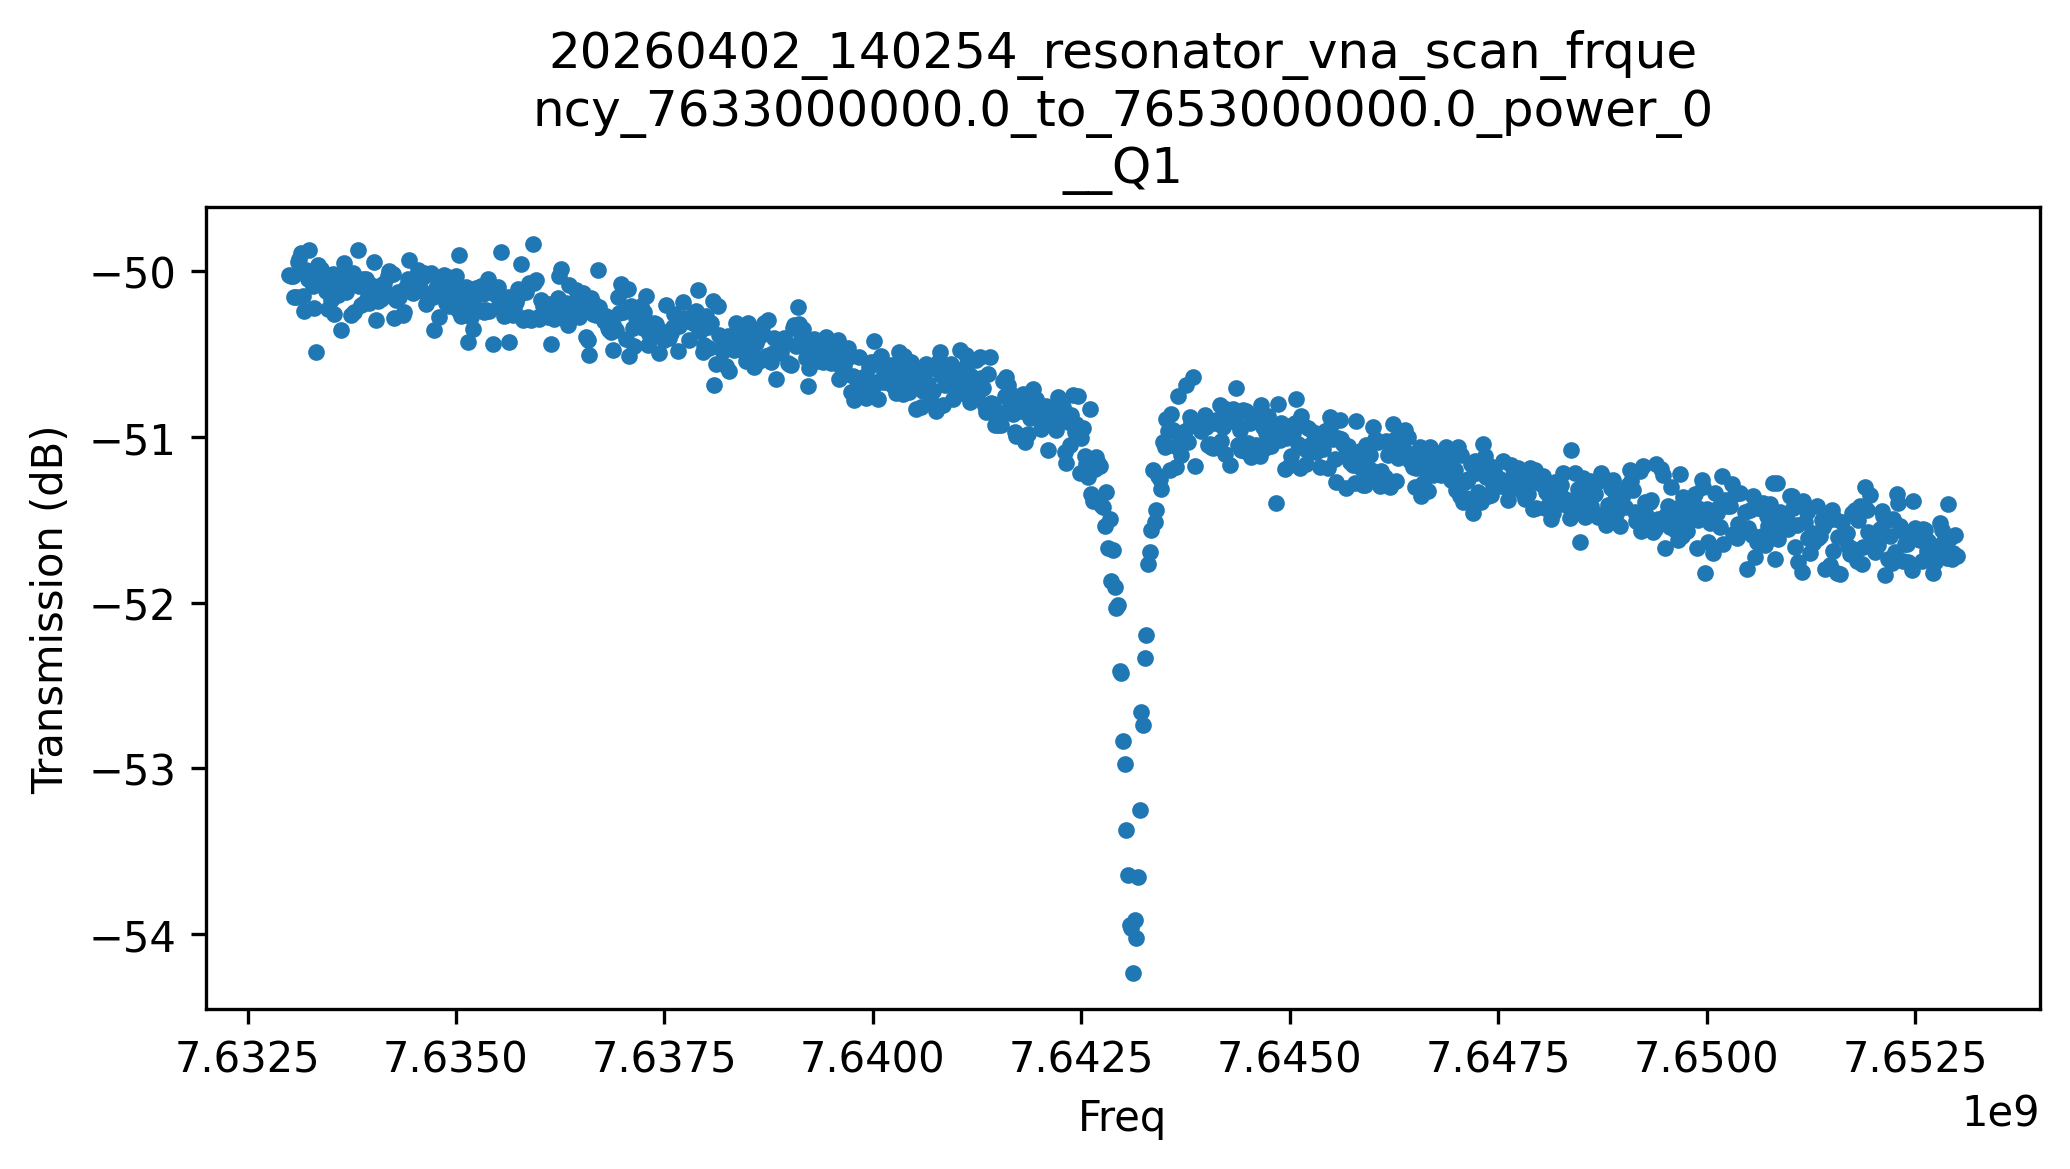

In [11]:
center = 7.643e9
delay =6.65e-8
span = 20e6 
start_f = center-span/2
stop_f = center+span/2
vna.reset()
vna.timeout(1000)
Q1.measure_resonator_spectroscopy_vna(start=start_f, stop = stop_f, 
                                           if_bandwidth = 3000,npts=1001, 
                                           averages = 100, MC=MC,power=-0,delay_t =delay, # in s
                                           analyze=True,close_fig=False,measure = 'S21')

Scan magnet current

VNA can wihile Sweep current source

In [4]:
import time

autorampdown = True #After for loop is finished, will the current ramp down back to 0 and turned off
rate = 2e-4 #current change rate in Amp per second
start_I = 0e-3
stop_I = 200e-3
step = 5e-3 #define steps
rampt = abs(step/rate)

center = 8.18e9
delay =6.5e-8
span = 200e6 
start_f = center-span/2
stop_f = center+span/2
power_s = -20
gs200.source_enabled = True # Turn output ON
gs200.trigger_ramp_to_level(start_I, abs((current-start_I)/step))
print('current =',start_I)
for sweepI in range(int(start_I/step),int(stop_I/step)+1,1):
    current = sweepI * step
    print('current =',current,rampt)
    gs200.trigger_ramp_to_level(current, rampt)
    time.sleep(rampt)
    #MC.set_sweep_function(swf.KST_VNA_sweep(vna,
    #                                            start_freq=start_f, stop_freq = stop_f, 
    #                                            if_bandwidth = 3000,npts=1001,
    #                                            power=power_s,
    #                                            delay_t =delay,
    #                                            measure = 'S21',
    #                                            force_reset=False))
    #    
    #MC.set_detector_function(det.KST_VNA_detector(vna))  
        
    #MC.run(name='vna_scan_frquency_{}_to_{}_at_magcurrent_{}_power_{}_'.format(start_f,stop_f,current,power_s))

if autorampdown:
    gs200.trigger_ramp_to_level(0, abs(current/step))
    print(0)
    time.sleep(abs(current/step)+2)
    gs200.source_enabled = False # Turn output OFF
    current = 0

current = 0.0
current = 0.0 25.0
current = 0.005 25.0
current = 0.01 25.0
current = 0.015 25.0
current = 0.02 25.0
current = 0.025 25.0
current = 0.03 25.0
current = 0.035 25.0
current = 0.04 25.0


KeyboardInterrupt: 

!!!Important 
If not autorampdown, ramp current back to 0 current before turn it off

Turn off gs200 safely

In [8]:
gs200.trigger_ramp_to_level(0, abs(current/rate))
time.sleep(abs(current/rate)+2)
gs200.source_enabled = False # Turn output ON
current = 0.00
print('current =',0)

current = 0


Turn off signal generator

In [9]:
sgen.on("OFF")

In [9]:
import time
sgen.on("OFF")
sgpower = 00 #-20 to 30dbm
pump_freq = 8.19009e9*2 #2f
#pump_freq = 8.1896e9 + 10e6 #2f
sgen.power(sgpower)
sgen.frequency(pump_freq)
sgen.on("ON")
span_freq = 1e6
step_freq = 1e4
for sweepf in range(int(pump_freq-span_freq),int(pump_freq+span_freq)+1,int(step_freq)):
    sgen.frequency(sweepf)
    time.sleep(10)